# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import ladder_ddpm, plot_acceptance_over_time, plot_acceptance_over_position

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

Running with 100 steps for [6. 5. 4. 3. 2. 1.]
f avg: -0.0001
f std: 0.0002
Time 87: Swap 6.0 and 5.0 tsr diff 0.0003000497817993164 mean acceptance 0.9999904632568359
f avg: -0.0004
f std: 0.0006
Time 87: Swap 4.0 and 3.0 tsr diff 0.0007486343383789062 mean acceptance 0.9999761581420898
f avg: -0.0021
f std: 0.0033
Time 87: Swap 2.0 and 1.0 tsr diff 0.0044558048248291016 mean acceptance 0.999857485294342
f avg: -0.0007
f std: 0.0011
Time 84: Swap 5.0 and 4.0 tsr diff 0.0007143020629882812 mean acceptance 0.9999638795852661
f avg: -0.0028
f std: 0.0047
Time 84: Swap 3.0 and 2.0 tsr diff 0.0023679733276367188 mean acceptance 0.999847948551178
f avg: -0.0006
f std: 0.0011
Time 81: Swap 6.0 and 5.0 tsr diff 0.000700831413269043 mean acceptance 0.9999712109565735
f avg: -0.0029
f std: 0.0051
Time 81: Swap 4.0 and 3.0 tsr diff 0.0017440319061279297 mean acceptance 0.9998660683631897
f avg: -0.0041
f std: 0.0067
Time 81: Swap 2.0 and 1.0 tsr diff 0.010269999504089355 mean acceptance 0.999817

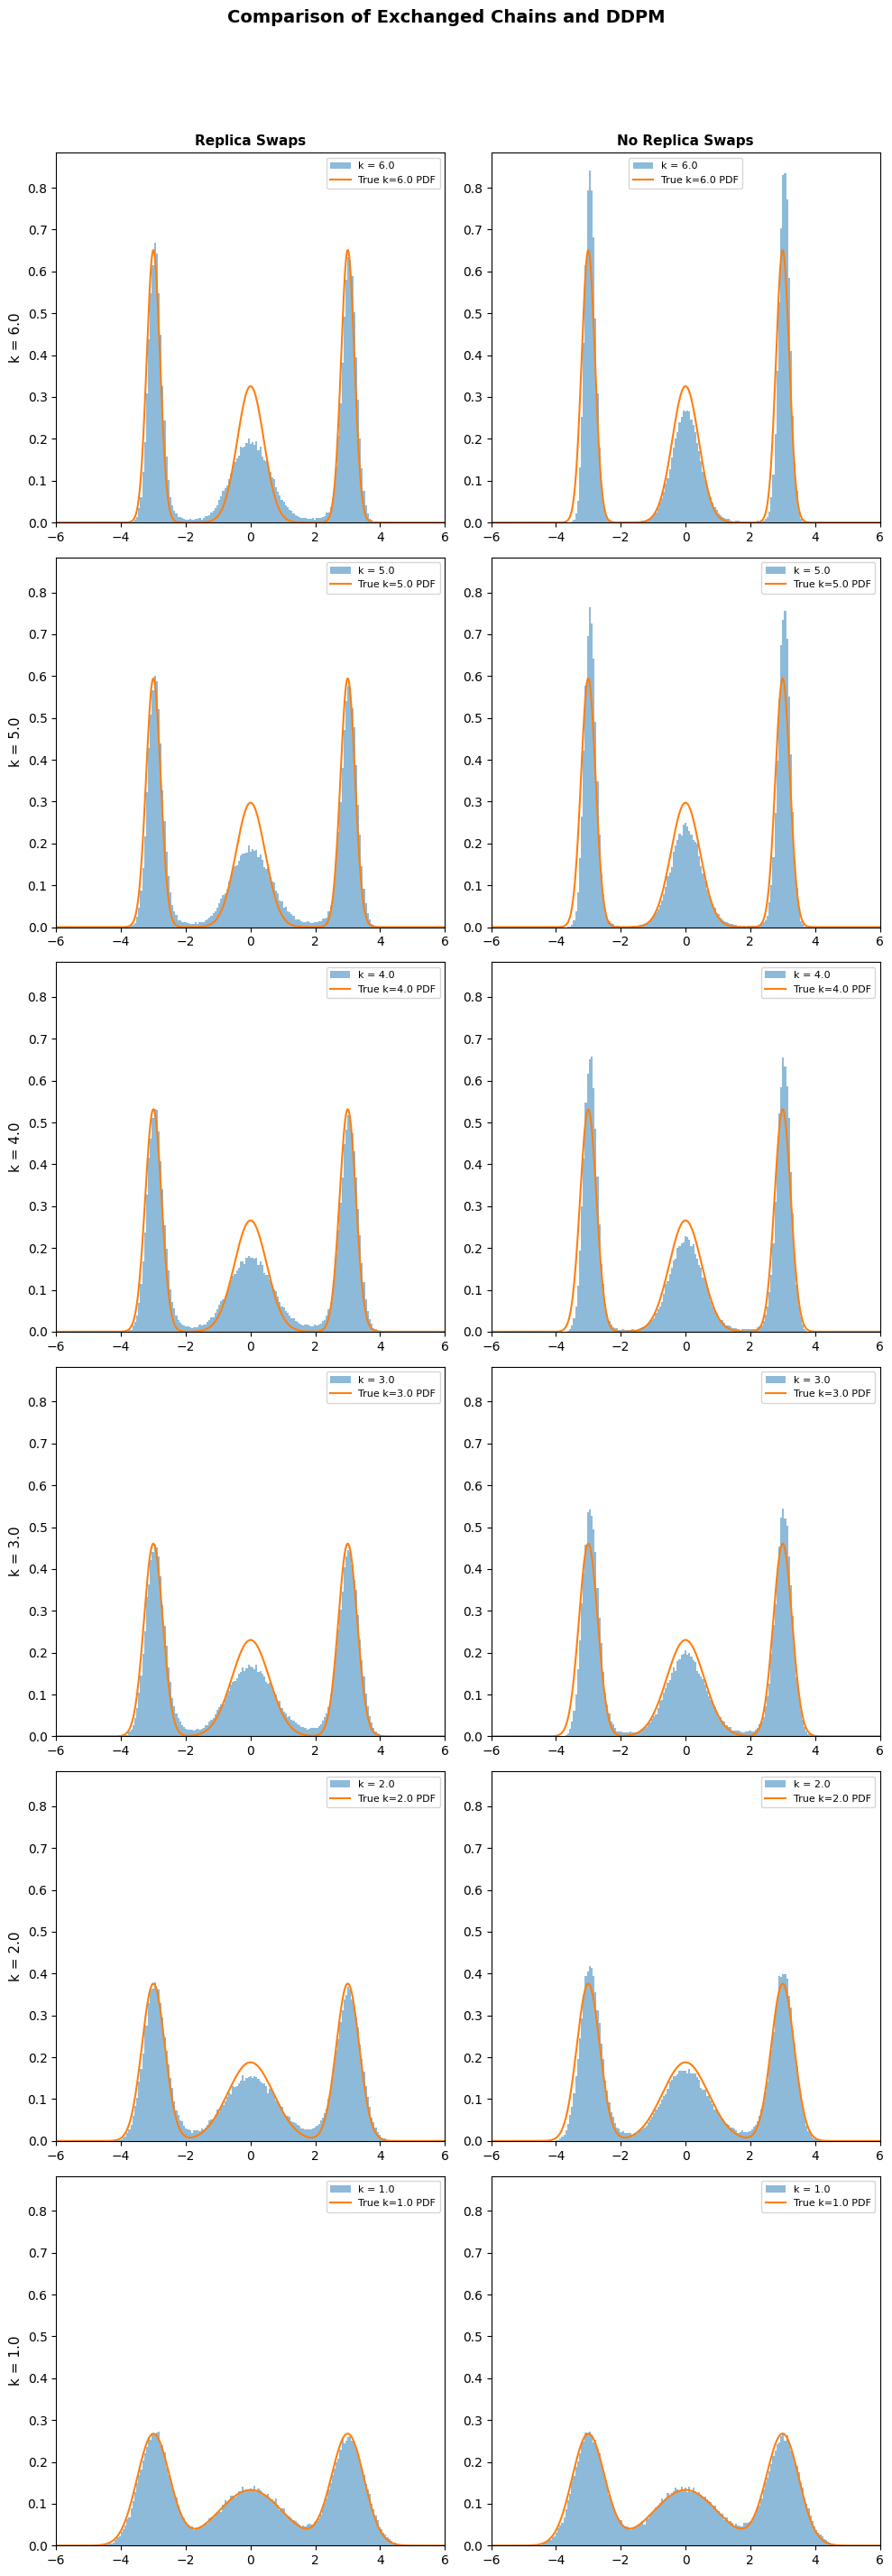

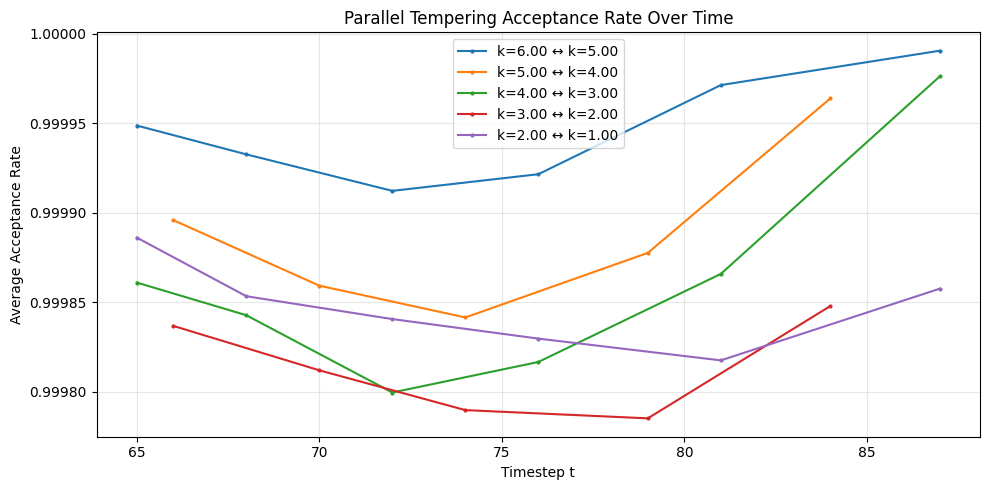

KeyError: 0

In [2]:
dataset_name = "composed"
k = 6.0
sigma = 0.5
step_scale = 1
n_langevin_steps = 3
n_replicas = 6

x_ladder, a_ladder = ladder_ddpm(dataset_name, k, sigma, step_scale, n_langevin_steps, n_replicas, x_limit=6, save_dir="figures", figsize_per_panel=(5,4), filename=None)
plot_acceptance_over_time(a_ladder)
_ = plot_acceptance_over_position(a_ladder, x_ladder[0][k])

87,
84,
81,
79,
76,
74,
72,
70,
68,
66,
65,


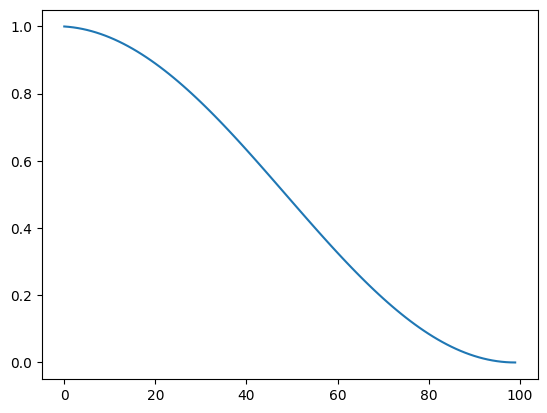

In [ ]:
import matplotlib.pyplot as plt
from src.schedule import alpha_bars
import torch

targets = [0.95, 0.925, 0.9, 0.875, 0.85, 0.825, 0.8, 0.775, 0.75, 0.725, 0.7]
for target in targets:
    idx = (alpha_bars.cpu() - target).abs().argmin().item()
    print(f"{100-idx},")

plt.plot(alpha_bars.cpu().numpy())
plt.show()